In [261]:
import numpy as np
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import re
from textblob import TextBlob
from wordcloud import WordCloud
import seaborn as sns
import matplotlib.pyplot as plt
import cufflinks as cf
%matplotlib inline 
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
cf.go_offline();
import plotly.graph_objs as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings("ignore")
warnings.warn("this will not show")

pd.set_option('display.max_columns', None)

In [275]:
df = pd.read_csv(r"D:\jn\amazon.csv")

In [263]:
df.head()

,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4,No issues.,23-07-2014,138,0,0,0,0,0.0,0.0
1,1,0mie,5,"Purchased this for my device, it worked as adv...",25-10-2013,409,0,0,0,0,0.0,0.0
2,2,1K3,4,it works as expected. I should have sprung for...,23-12-2012,715,0,0,0,0,0.0,0.0
3,3,1m2,5,This think has worked out great.Had a diff. br...,21-11-2013,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5,"Bought it with Retail Packaging, arrived legit...",13-07-2013,513,0,0,0,0,0.0,0.0


In [264]:
df.tail()

,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
4910,4910,"ZM ""J""",1,I bought this Sandisk 16GB Class 10 to use wit...,23-07-2013,503,0,0,0,0,0.0,0.0
4911,4911,Zo,5,Used this for extending the capabilities of my...,22-08-2013,473,0,0,0,0,0.0,0.0
4912,4912,Z S Liske,5,Great card that is very fast and reliable. It ...,31-03-2014,252,0,0,0,0,0.0,0.0
4913,4913,Z Taylor,5,Good amount of space for the stuff I want to d...,16-09-2013,448,0,0,0,0,0.0,0.0
4914,4914,Zza,5,I've heard bad things about this 64gb Micro SD...,01-02-2014,310,0,0,0,0,0.0,0.0


In [265]:
df=df.sort_values("wilson_lower_bound", ascending = False)
df.drop('Unnamed: 0', inplace= True, axis=1)
df.head()

,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
2031,"Hyoun Kim ""Faluzure""",5,[[ UPDATE - 6/19/2014 ]]So my lovely wife boug...,05-01-2013,702,1952,68,2020,1884,0.966337,0.957544
3449,NLee the Engineer,5,I have tested dozens of SDHC and micro-SDHC ca...,26-09-2012,803,1428,77,1505,1351,0.948837,0.936519
4212,SkincareCEO,1,NOTE: please read the last update (scroll to ...,08-05-2013,579,1568,126,1694,1442,0.925620,0.912139
317,"Amazon Customer ""Kelly""",1,"If your card gets hot enough to be painful, it...",09-02-2012,1033,422,73,495,349,0.852525,0.818577
4672,Twister,5,Sandisk announcement of the first 128GB micro ...,03-07-2014,158,45,4,49,41,0.918367,0.808109


In [266]:
def missing_values_analysis(df):
    na_columns_ = [col for col in df.columns if df[col].isnull().sum() > 0]
    n_miss = df[na_columns_].isnull().sum().sort_values(ascending = True)
    ratio_ = (df[na_columns_].isnull().sum() / df.shape[0]* 100).sort_values(ascending = True)
    missing_df = pd.concat([n_miss, np.round(ratio_, 2)], axis = 1, keys = ['Missing Values', 'Ratio'])
    missing_df = pd.DataFrame(missing_df)
    return missing_df

def check_dataframe(df, head =5, tail =5):
    print("SHAPE".center(82,'~'))
    print('Rows:{}'.format(df.shape[0]))
    print('Columns:{}'.format(df.shape[1]))
    print("TYPES".center(82,'~'))
    print(df.dtypes)
    print("".center(82,'~'))
    print(missing_values_analysis(df))
    print("DUPLICATED VALUES".center(83,'~'))
    print(df.duplicated().sum())
    print("QUANTILES".center(82,'~'))
    print(df.quantile([0, 0.05, 0.50, 0.95, 0.99, 1], numeric_only=True).T)

check_dataframe(df)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~SHAPE~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Rows:4915
Columns:11
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~TYPES~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
reviewerName             object
overall                   int64
reviewText               object
reviewTime               object
day_diff                  int64
helpful_yes               int64
helpful_no                int64
total_vote                int64
score_pos_neg_diff        int64
score_average_rating    float64
wilson_lower_bound      float64
dtype: object
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
              Missing Values  Ratio
reviewerName               1   0.02
reviewText                 1   0.02
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~DUPLICATED VALUES~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
0
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~QUANTILES~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                       0.00  0.05   0.50        0.95       0.99         1.00
overall   

In [267]:
def check_class(dataframe):
    nunique_df= pd.DataFrame({'Variable': dataframe.columns, 'Classes': [dataframe[i].nunique() \
                                                                         for i  in dataframe.columns]})
    nunique_df=nunique_df.sort_values('Classes', ascending = False)
    nunique_df=nunique_df.reset_index(drop = True)
    return nunique_df

check_class(df)

,Variable,Classes
0,reviewText,4912
1,reviewerName,4594
2,reviewTime,690
3,day_diff,690
4,wilson_lower_bound,40
5,score_average_rating,28
6,score_pos_neg_diff,27
7,total_vote,26
8,helpful_yes,23
9,helpful_no,17


In [268]:
constraints = ['#264653','#2A9D8F','#E9C46A','#F4A261','#E76F51']
def categorical_variable_summary(df, column_name):
    value_counts = df[column_name].value_counts()
    percentages = (value_counts / value_counts.sum() * 100).round(1)

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('Category Counts', 'Category Distribution (%)'),
        specs=[[{"type": "xy"}, {"type": "domain"}]]
    )

    # Horizontal Bar Chart with counts + %
    fig.add_trace(
        go.Bar(
            x=value_counts.values,
            y=[str(i) for i in value_counts.index],
            text=[f"{v} ({p}%)" for v, p in zip(value_counts.values, percentages)],
            textposition='auto',
            orientation='h',   # horizontal for better readability
            marker=dict(color=constraints, line=dict(color='#DBE6EC', width=1)),
            showlegend=False,
            name=column_name
        ),
        row=1, col=1
    )

    # Pie Chart with % inside
    fig.add_trace(
        go.Pie(
            labels=value_counts.index,
            values=value_counts.values,
            text=[f"{p}%" for p in percentages],
            textinfo="label+text",
            textfont=dict(size=14),
            name=column_name,
            marker=dict(colors=constraints)
        ),
        row=1, col=2
    )

    # Layout polish
    fig.update_layout(
        title={
            'text': f"Categorical Summary: {column_name}",
            'y': 0.9,
            'x': 0.5,
            'xanchor': 'center',
            'yanchor': 'top'
        },
        template='plotly_white',
        font=dict(size=13),
        height=500,
        width=900
    )

    iplot(fig)

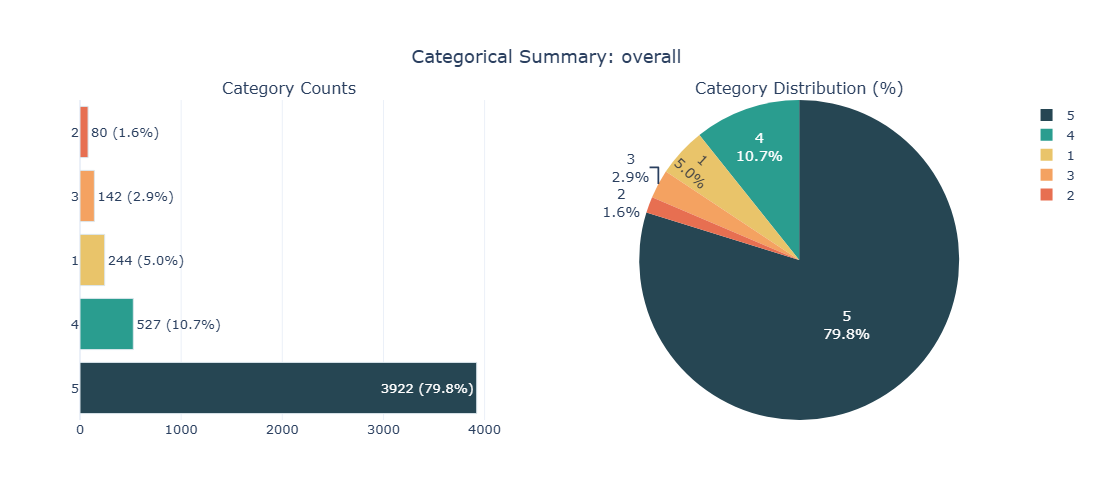

In [237]:
categorical_variable_summary(df, 'overall')

In [269]:
df.reviewText.head()


2031    [[ UPDATE - 6/19/2014 ]]So my lovely wife boug...
3449    I have tested dozens of SDHC and micro-SDHC ca...
4212    NOTE:  please read the last update (scroll to ...
317     If your card gets hot enough to be painful, it...
4672    Sandisk announcement of the first 128GB micro ...
Name: reviewText, dtype: object

In [270]:
review_example = df.reviewText[4212]
review_example

'NOTE:  please read the last update (scroll to the bottom) - I\'m leaving this review as 1 star as it appears to help others who purchased and had a similar experience.I give SanDisk 5 stars for customer service and 1 star for the product (for those manufactured in the past)  For those newly manufactured products that contain the software ROM fix, I\'d give the product 5 stars.To all those who purchased this card due to all the great reviews.... and then used it in a Galaxy S4 (GS4) smartphone for storage, the solution to the problem is not one you can solve without returning the card to SanDisk for a replacement under warranty.  Believe me I tried everything that the Google searches returned as solutions... formatting as exFAT, formatting in the GS4 then copying data to the card while in the phone etc.... nothing worked... and so now please stop pulling out your hair and hopefully you will get the same result which I hope to get soon (just RMA\'d and will send it back tomorrow for a f

In [245]:
review_example= re.sub("[^a-zA-Z]",'',review_example)
review_example

'NOTEpleasereadthelastupdatescrolltothebottomImleavingthisreviewasstarasitappearstohelpotherswhopurchasedandhadasimilarexperienceIgiveSanDiskstarsforcustomerserviceandstarfortheproductforthosemanufacturedinthepastForthosenewlymanufacturedproductsthatcontainthesoftwareROMfixIdgivetheproductstarsToallthosewhopurchasedthiscardduetoallthegreatreviewsandthenuseditinaGalaxySGSsmartphoneforstoragethesolutiontotheproblemisnotoneyoucansolvewithoutreturningthecardtoSanDiskforareplacementunderwarrantyBelievemeItriedeverythingthattheGooglesearchesreturnedassolutionsformattingasexFATformattingintheGSthencopyingdatatothecardwhileinthephoneetcnothingworkedandsonowpleasestoppullingoutyourhairandhopefullyyouwillgetthesameresultwhichIhopetogetsoonjustRMAdandwillsenditbacktomorrowforafreereplacementunderwarrantyTheproblemAsconfirmedfromtheSanDiskcustomersupportrepwhenIaskedspecificallyaskedhimWhenusedintheGSthiscardwillunmountitselfinadvertentlymaybetrueonlyforcardsmanufacturedbeforetheROMpatchdescribedb

In [271]:
review_example=review_example.lower().split()

In [272]:
review_example

['note:',
 'please',
 'read',
 'the',
 'last',
 'update',
 '(scroll',
 'to',
 'the',
 'bottom)',
 '-',
 "i'm",
 'leaving',
 'this',
 'review',
 'as',
 '1',
 'star',
 'as',
 'it',
 'appears',
 'to',
 'help',
 'others',
 'who',
 'purchased',
 'and',
 'had',
 'a',
 'similar',
 'experience.i',
 'give',
 'sandisk',
 '5',
 'stars',
 'for',
 'customer',
 'service',
 'and',
 '1',
 'star',
 'for',
 'the',
 'product',
 '(for',
 'those',
 'manufactured',
 'in',
 'the',
 'past)',
 'for',
 'those',
 'newly',
 'manufactured',
 'products',
 'that',
 'contain',
 'the',
 'software',
 'rom',
 'fix,',
 "i'd",
 'give',
 'the',
 'product',
 '5',
 'stars.to',
 'all',
 'those',
 'who',
 'purchased',
 'this',
 'card',
 'due',
 'to',
 'all',
 'the',
 'great',
 'reviews....',
 'and',
 'then',
 'used',
 'it',
 'in',
 'a',
 'galaxy',
 's4',
 '(gs4)',
 'smartphone',
 'for',
 'storage,',
 'the',
 'solution',
 'to',
 'the',
 'problem',
 'is',
 'not',
 'one',
 'you',
 'can',
 'solve',
 'without',
 'returning',
 'the'

In [279]:
rt= lambda x: re.sub("[^a-zA-Z]",' ',str(x))
df["reviewText"]=df["reviewText"].map(rt)
df["reviewText"]=df["reviewText"].str.lower()
df.head

<bound method NDFrame.head of       Unnamed: 0  reviewerName  overall  \
0              0           NaN        4   
1              1          0mie        5   
2              2           1K3        4   
3              3           1m2        5   
4              4  2&amp;1/2Men        5   
...          ...           ...      ...   
4910        4910        ZM "J"        1   
4911        4911            Zo        5   
4912        4912     Z S Liske        5   
4913        4913      Z Taylor        5   
4914        4914           Zza        5   

                                             reviewText  reviewTime  day_diff  \
0                                            no issues   23-07-2014       138   
1     purchased this for my device  it worked as adv...  25-10-2013       409   
2     it works as expected  i should have sprung for...  23-12-2012       715   
3     this think has worked out great had a diff  br...  21-11-2013       382   
4     bought it with retail packaging  arrived l

In [280]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
df[['polarity','subjectivity']]=df['reviewText'].apply(lambda Text:pd.Series(TextBlob(Text).sentiment))

for index, row in df['reviewText'].items():

    score=SentimentIntensityAnalyzer().polarity_scores(row)

    neg=score['neg']
    neu=score['neu']
    pos=score['pos']
    if neg>pos:
        df.loc[index, 'sentiment']="Negative"
    elif pos>neg:
        df.loc[index, 'sentiment']="Positive"
    else:
        df.loc[index, 'sentiment']="Neutral"

In [281]:
df[df["sentiment"]=="Positive"].sort_values("wilson_lower_bound", ascending=False).head(5)

,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound,polarity,subjectivity,sentiment
2031,2031,"Hyoun Kim ""Faluzure""",5,update so my lovely wife boug...,05-01-2013,702,1952,68,2020,1884,0.966337,0.957544,0.163859,0.562259,Positive
3449,3449,NLee the Engineer,5,i have tested dozens of sdhc and micro sdhc ca...,26-09-2012,803,1428,77,1505,1351,0.948837,0.936519,0.103870,0.516435,Positive
4212,4212,SkincareCEO,1,note please read the last update scroll to ...,08-05-2013,579,1568,126,1694,1442,0.925620,0.912139,0.212251,0.505394,Positive
317,317,"Amazon Customer ""Kelly""",1,if your card gets hot enough to be painful it...,09-02-2012,1033,422,73,495,349,0.852525,0.818577,0.143519,0.494207,Positive
4672,4672,Twister,5,sandisk announcement of the first gb micro ...,03-07-2014,158,45,4,49,41,0.918367,0.808109,0.172332,0.511282,Positive


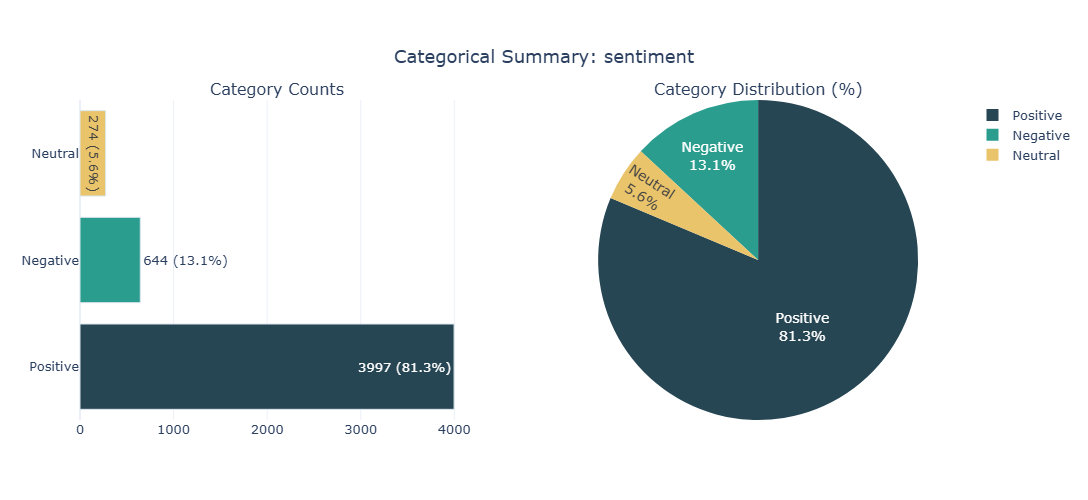

In [282]:
categorical_variable_summary(df,'sentiment')